<a href="https://colab.research.google.com/github/Abdi-dotcom/msc-seismic-monitoring-dissertation/blob/main/AM_R6C8A_merged.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import glob
from google.colab import drive

drive.mount('/content/drive')

folder_path = '/content/drive/MyDrive/Colab Notebooks/Seismic_Folder/'


files = os.listdir(folder_path)
print("Files found in folder:", files)

seismic_files = glob.glob(os.path.join(folder_path, "*spectra.csv"))
print(f"Total spectra files detected: {len(seismic_files)}")

Mounted at /content/drive
Files found in folder: ['AM-R6C8A-00-EHZ-20241224-spectra.csv', 'AM-R6C8A-00-EHZ-20241227-spectra.csv', 'AM-R6C8A-00-EHZ-20250102-spectra.csv', 'AM-R6C8A-00-EHZ-20250103-spectra.csv', 'AM-R6C8A-00-EHZ-20241228-spectra.csv', 'AM-R6C8A-00-EHZ-20250121-spectra.csv', 'AM-R6C8A-00-EHZ-20250110-spectra.csv', 'AM-R6C8A-00-EHZ-20250115-spectra.csv', 'AM-R6C8A-00-EHZ-20241225-spectra.csv', 'AM-R6C8A-00-EHZ-20250106-spectra.csv', 'AM-R6C8A-00-EHZ-20241231-spectra.csv', 'AM-R6C8A-00-EHZ-20250117-spectra.csv', 'AM-R6C8A-00-EHZ-20250120-spectra.csv', 'AM-R6C8A-00-EHZ-20241226-spectra.csv', 'AM-R6C8A-00-EHZ-20250114-spectra.csv', 'AM-R6C8A-00-EHZ-20241230-spectra.csv', 'AM-R6C8A-00-EHZ-20250118-spectra.csv', 'AM-R6C8A-00-EHZ-20250105-spectra.csv', 'AM-R6C8A-00-EHZ-20250104-spectra.csv', 'AM-R6C8A-00-EHZ-20250119-spectra.csv', 'AM-R6C8A-00-EHZ-20241229-spectra.csv', 'AM-R6C8A-00-EHZ-20250109-spectra.csv', 'AM-R6C8A-00-EHZ-20250107-spectra.csv', 'AM-R6C8A-00-EHZ-20250113-spec

In [ ]:
import pandas as pd
import glob

li = []
for filename in seismic_files:

    df = pd.read_csv(filename, index_col=0)
    li.append(df)

df_seismic_merged = pd.concat(li, axis=0)

df_seismic_merged = df_seismic_merged.reset_index()

df_seismic_merged.rename(columns={df_seismic_merged.columns[0]: 'timestamp'}, inplace=True)

df_seismic_merged['timestamp'] = pd.to_datetime(df_seismic_merged['timestamp'])
df_seismic_merged = df_seismic_merged.sort_values('timestamp')

df_seismic_merged.to_csv('/content/drive/MyDrive/Colab Notebooks/AM_R6C8A_merged.csv', index=False)
print("Master file saved successfully!")

Master file saved successfully!


In [ ]:
df_seismic_merged.head()

,timestamp,0.00,0.25,0.50,0.75,1.00,1.25,1.50,1.75,2.00,...,47.50,47.75,48.00,48.25,48.50,48.75,49.00,49.25,49.50,49.75
0,2024-12-24 00:00:00,62.26,80.65,65.20,53.98,50.15,59.13,93.55,90.52,63.62,...,54.77,50.58,48.01,51.19,46.92,41.36,27.53,15.83,4.23,-2.32
1,2024-12-24 00:15:00,61.13,82.53,64.63,49.63,39.59,40.55,59.45,67.55,54.55,...,54.98,52.24,50.24,42.22,35.88,29.76,20.68,14.76,0.08,-10.36
2,2024-12-24 00:30:00,62.80,81.95,64.60,49.17,40.16,39.94,57.35,68.35,55.59,...,51.85,51.51,45.11,34.84,30.05,28.34,14.92,6.74,-2.86,-4.03
3,2024-12-24 00:45:00,61.27,82.45,64.48,46.91,36.95,36.80,55.18,65.13,53.00,...,47.70,44.40,43.11,41.03,32.96,29.41,22.63,13.29,4.17,-8.99
4,2024-12-24 01:00:00,62.58,81.82,65.42,49.34,39.07,38.68,59.57,66.07,52.28,...,53.67,51.85,47.11,35.74,32.85,22.84,16.05,3.49,-9.22,-19.61


Missing values in seismic data:
0

Duplicate timestamps: 0

Start date: 2024-12-24 00:00:00
End date: 2025-03-31 23:44:00


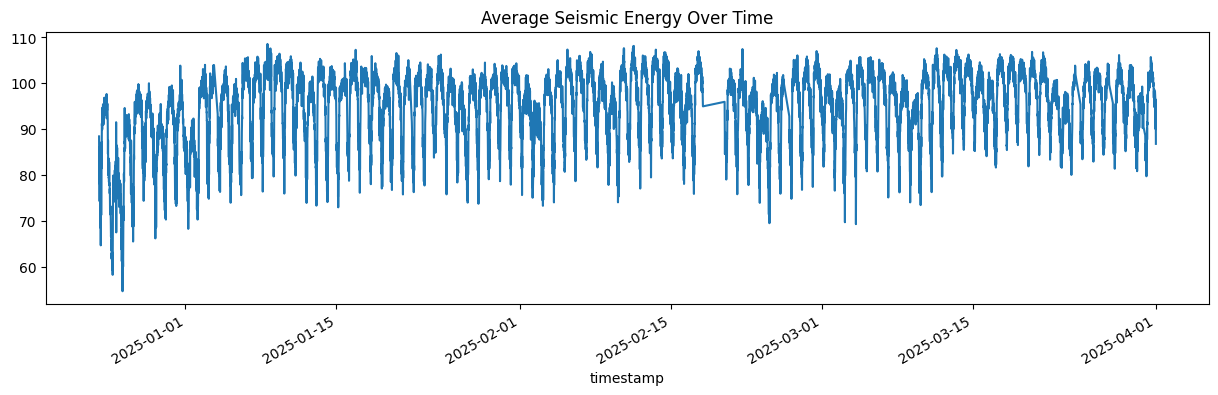

In [ ]:
# Checks for missing values (common after merges)
print("Missing values in seismic data:")
print(df_seismic_merged.isnull().sum().sum())

# Check for duplicates (e.g., if we  accidentally ran the merge twice)
print(f"\nDuplicate timestamps: {df_seismic_merged.duplicated('timestamp').sum()}")

# Checks the date range to ensure it covers my full period (Dec 24 - March 24)
print(f"\nStart date: {df_seismic_merged['timestamp'].min()}")
print(f"End date: {df_seismic_merged['timestamp'].max()}")

# Quick visual check of the total energy over time
import matplotlib.pyplot as plt
df_seismic_merged.set_index('timestamp').mean(axis=1).plot(figsize=(15, 4), title="Average Seismic Energy Over Time")
plt.show()

In [ ]:
print(f"Number of individual datasets combined: {len(seismic_files)}")
print(f"Merged DataFrame dimensions: {df_seismic_merged.shape[0]} rows, {df_seismic_merged.shape[1]} columns")

Number of individual datasets combined: 96
Merged DataFrame dimensions: 9026 rows, 201 columns


In [ ]:
import os
import glob
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# Telraam
df_telraam = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/telraam.csv')
df_telraam['timestamp'] = pd.to_datetime(df_telraam['Date and Time (Local)'], format='mixed')
df_telraam.set_index('timestamp', inplace=True)

# Drakewell
df_drakewell = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/drakewell.csv')
df_drakewell['timestamp'] = pd.to_datetime(df_drakewell['timestamp'], format='mixed')
df_drakewell.set_index('timestamp', inplace=True)

# Seismic
df_seismic = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/AM_R6C8A_merged.csv')
df_seismic['timestamp'] = pd.to_datetime(df_seismic['timestamp'])
df_seismic.set_index('timestamp', inplace=True)


# For Telraam — identifys which columns are counts vs speeds
print("Telraam columns:", df_telraam.columns.tolist())
# Count columns: anything with 'count', 'Total'
# Speed columns: anything with 'speed', 'Speed', 'km/h'

telraam_count_cols = [c for c in df_telraam.columns if 'count' in c.lower() or 'total' in c.lower()]
telraam_speed_cols = [c for c in df_telraam.columns if 'speed' in c.lower() or 'km/h' in c]

print(f"Telraam counts: {telraam_count_cols}")
print(f"Telraam speeds: {telraam_speed_cols}")


print("\nDrakewell columns:", df_drakewell.columns.tolist())
drakewell_count_cols = [c for c in df_drakewell.columns if 'count' in c.lower() or 'total' in c.lower()]
drakewell_speed_cols = [c for c in df_drakewell.columns if 'speed' in c.lower() or 'km/h' in c]

print(f"Drakewell counts: {drakewell_count_cols}")
print(f"Drakewell speeds: {drakewell_speed_cols}")


# Telraam: sum counts, mean speeds
telraam_counts_hourly = df_telraam[telraam_count_cols].resample('h').sum()
telraam_speeds_hourly = df_telraam[telraam_speed_cols].resample('h').mean()
telraam_hourly = pd.concat([telraam_counts_hourly, telraam_speeds_hourly], axis=1)

# Drakewell: sum counts, mean speeds
drakewell_counts_hourly = df_drakewell[drakewell_count_cols].resample('h').sum()
drakewell_speeds_hourly = df_drakewell[drakewell_speed_cols].resample('h').mean()
drakewell_hourly = pd.concat([drakewell_counts_hourly, drakewell_speeds_hourly], axis=1)

# Seismic: mean
seismic_hourly = df_seismic.resample('h').mean()


df_man1_hourly = df_man1.select_dtypes(include=['number']).resample('h').mean()


master_df = pd.concat([
    seismic_hourly,
    telraam_hourly,
    drakewell_hourly,
    df_man1_hourly[['NO2']]
], axis=1, join='inner')

print(f"\nFinal merged shape: {master_df.shape}")
print(f"Date range: {master_df.index.min()} to {master_df.index.max()}")

Telraam columns: ['Segment ID', 'Street', 'City', 'Date and Time (Local)', 'Pedestrian Total', 'Bike Total', 'Car Total', 'Large vehicle Total', 'Night Total', 'Speed V85 km/h', 'Speed Car 0-10 km/h (%)', 'Speed Car 10-20 km/h (%)', 'Speed Car 20-30 km/h (%)', 'Speed Car 30-40 km/h (%)', 'Speed Car 40-50 km/h (%)', 'Speed Car 50-60 km/h (%)', 'Speed Car 60-70 km/h (%)', 'Speed Car 70+ km/h (%)', 'Pedestrian (A > B)', 'Pedestrian (B > A)', 'Bike (A > B)', 'Bike (B > A)', 'Car (A > B)', 'Car (B > A)', 'Heavy (A > B)', 'Heavy (B > A)', 'Mode bicycle (A > B)', 'Mode bicycle(B > A)', 'Mode bus (A > B)', 'Mode bus (B > A)', 'Mode car (A > B)', 'Mode car (B > A)', 'Mode lighttruck (A > B)', 'Mode lighttruck (B > A)', 'Mode motorcycle (A > B)', 'Mode motorcycle (B > A)', 'Mode pedestrian (A > B)', 'Mode pedestrian (B > A)', 'Mode stroller (A > B)', 'Mode stroller (B > A)', 'Mode tractor (A > B)', 'Mode tractor(B > A)', 'Mode trailer (A > B)', 'Mode trailer(B > A)', 'Mode truck (A > B)', 'Mode 

In [ ]:
# Check speed statistics after fix
speed_cols = [c for c in master_df.columns if 'speed' in c.lower()]
for col in speed_cols:
    print(f"\n{col}:")
    print(f"  Min: {master_df[col].min():.1f}")
    print(f"  Max: {master_df[col].max():.1f}")
    print(f"  Mean: {master_df[col].mean():.1f}")
    print(f"  Median: {master_df[col].median():.1f}")

    # Check for any remaining extreme values
    extreme = master_df[master_df[col] > 100]
    print(f"  Values > 100 km/h: {len(extreme)}")
    if len(extreme) > 0:
        print(f"    Sample: {extreme[col].head(3).tolist()}")


Speed V85 km/h:
  Min: 4.0
  Max: 53.5
  Mean: 30.1
  Median: 30.2
  Values > 100 km/h: 0

Speed Car 0-10 km/h (%):
  Min: 0.0
  Max: 51.6
  Mean: 3.0
  Median: 0.0
  Values > 100 km/h: 0

Speed Car 10-20 km/h (%):
  Min: 0.0
  Max: 64.2
  Mean: 12.7
  Median: 0.0
  Values > 100 km/h: 0

Speed Car 20-30 km/h (%):
  Min: 0.0
  Max: 74.1
  Mean: 18.1
  Median: 0.0
  Values > 100 km/h: 0

Speed Car 30-40 km/h (%):
  Min: 0.0
  Max: 56.7
  Mean: 5.7
  Median: 0.0
  Values > 100 km/h: 0

Speed Car 40-50 km/h (%):
  Min: 0.0
  Max: 29.2
  Mean: 0.8
  Median: 0.0
  Values > 100 km/h: 0

Speed Car 50-60 km/h (%):
  Min: 0.0
  Max: 15.6
  Mean: 0.1
  Median: 0.0
  Values > 100 km/h: 0

Speed Car 60-70 km/h (%):
  Min: 0.0
  Max: 12.5
  Mean: 0.1
  Median: 0.0
  Values > 100 km/h: 0

Speed Car 70+ km/h (%):
  Min: 0.0
  Max: 4.2
  Mean: 0.0
  Median: 0.0
  Values > 100 km/h: 0

Vehicle speed  - Vehicles Speed southwest bound (km/h):
  Min: 21.8
  Max: 51.5
  Mean: 42.2
  Median: 42.8
  Values >

In [ ]:
master_df.to_csv('/content/drive/MyDrive/Colab Notebooks/master_merged_data.csv', index=True)
print("master_df exported successfully to 'master_merged_data.csv'!")

master_df exported successfully to 'master_merged_data.csv'!
